In [1]:
%load_ext autoreload
%autoreload 2

from math import pi
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.qubits.fluxonium import Fluxonium

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 100
plt.style.use("fluxoniumcr.plotting.paper")

In [2]:
dataset = xr.load_dataset(DATA_DIR/"zero_collision_yield/dataset.hdf5").mean('repetition')

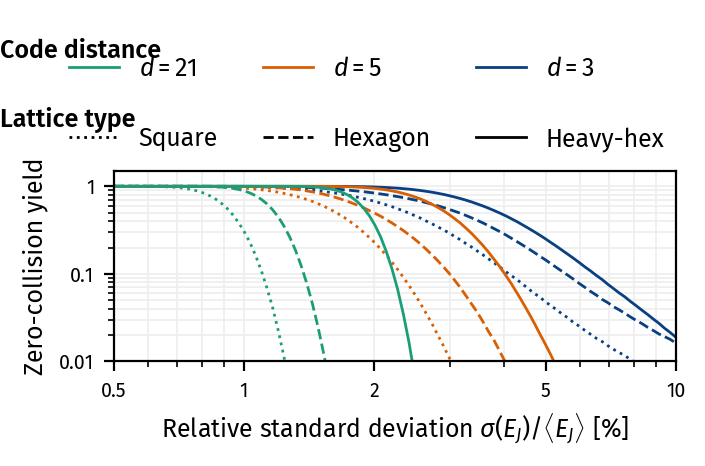

In [3]:
fig, ax = plt.subplots(
    figsize=(85/25.4, 55/25.4),
)

for i, lattice in enumerate(['heavyhex', 'hexagon', 'square']):
    ds = dataset.sel(lattice=lattice)
    for j, dist in enumerate([3, 5, 21]):
        ax.plot(
            ds.EJ_rel_sdev,
            ds.sel(distance=dist).zero_collision_prob,
            c=["C0", "C1", "C4"][j],
            ls=["-", "--", ":"][i],
            zorder=-100 + 10*j + -i,
        )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.005, 0.1)
ax.set_ylim(0.01, 1.5)

ax.set_xlabel(r"Relative standard deviation $\sigma(E_J)/\langle E_J\rangle$ [%]")
ax.set_xticks(
    [0.005, 0.01, 0.02, 0.05, 0.10],
    ["0.5", "1", "2", "5", "10"],
)
# ax.xaxis.set_major_formatter(lambda x, pos: f"{x*100}")
ax.set_ylabel("Zero-collision yield")
ax.set_yticks([0.01, 0.1, 1.0], ["0.01", "0.1", "1"])
# ax.axhline(0.1, c=plt.rcParams['grid.color'], zorder=-1000)



from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([], [], color='C4', ls="-", label='$d=21$'),
    Line2D([], [], color='black', ls=":", label='Square'),
    Line2D([], [], color='C1', ls="-", label='$d=5$'),
    Line2D([], [], color='black', ls="--", label='Hexagon'),
    Line2D([], [], color='C0', ls="-", label='$d=3$'),
    Line2D([], [], color='black', ls="-", label='Heavy-hex'),
]

legend = ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(1.02, 1.72),
    columnspacing=1.8,
    labelspacing=1.8,
    fancybox=True,
    ncol=3,
)
## Move titles to the left 
for item, label in zip(legend.legend_handles, legend.texts):
    if label.get_text().startswith("Title"):
        if label.get_text() == "Title 1":
            label.set_text('Lattice type')
        elif label.get_text() == "Title 2":
            label.set_text('Code distance')
        width = item.get_window_extent(fig.canvas.get_renderer()).width
        label.set_ha('left')
        label.set_fontweight('semibold')
        label.set_position((-1.5*width,0))

ax.annotate(
    "Code distance",
    (0, 1.0),
    (0, -24.7 + 14),
    xycoords="figure fraction",
    textcoords='offset points',
    ha='left',
    va='bottom',
    fontweight='semibold',
)

ax.annotate(
    "Lattice type",
    (0, 1.0),
    (0, -49.9 + 14),
    xycoords="figure fraction",
    textcoords='offset points',
    ha='left',
    va='bottom',
    fontweight='semibold',
)
# ax.set_axisbelow(True)
ax.vlines(
    ax.get_xticks(minor=True),
    *ax.get_ylim(),
    ec='#eee',
    lw=plt.rcParams['xtick.minor.width'],
    zorder=-1e3,
)
ax.vlines(
    ax.get_xticks(minor=False),
    *ax.get_ylim(),
    ec='#eee',
    lw=plt.rcParams['xtick.minor.width'],
    zorder=-1e3,
)
ax.hlines(
    ax.get_yticks(minor=True),
    *ax.get_xlim(),
    ec='#eee',
    lw=plt.rcParams['ytick.minor.width'],
    zorder=-1e3,
)
ax.hlines(
    ax.get_yticks(minor=False),
    *ax.get_xlim(),
    ec='#eee',
    lw=plt.rcParams['ytick.minor.width'],
    zorder=-1e3,
)

fig.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.2,
    top=0.64,
)
fig.savefig("zero_collision_yield.pdf")

In [11]:
lattice = 'heavyhex'
distance = 21
zero_collision_yield_thresh = 0.5

i = np.argmin(
    dataset.sel(lattice=lattice, distance=distance).zero_collision_prob.data
    > zero_collision_yield_thresh
)

print(
    f"Required RSD for {lattice} d={distance} and yield > {zero_collision_yield_thresh}:\n"
    f"{dataset.EJ_rel_sdev[i].item() * 100:.2f} %"
)

Required RSD for heavyhex d=21 and yield > 0.5:
1.95 %
